In [43]:
import numpy as np
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import scipy

### Global heritability (Champollion V1)

In [44]:
# heritability results
path_to_Champollion = "/home/ad279118/ukb/26irene_AD_UKB_optim/results/Champollion_V1_32"
population="White"

# Setup for the report
with open(f"{path_to_Champollion}/list_model_32PCs.txt") as f:
    regions_models = [line.strip() for line in f if line.strip() and not line.strip().startswith("#")]

# explained_variance_ratio
path_variance = "/neurospin/dico/adufournet/2026_PCA_on_latent/ChampollionV1_32"

verbose = False

dic_results = {"region":[], 
               "model":[],
               "h2":[], 
               "se":[],
               }


Loaded 56 regions.
Saved to /neurospin/dico/adufournet/2026_PCA_on_latent/ChampollionV1_32/h2_vs_npc_boxplot.png


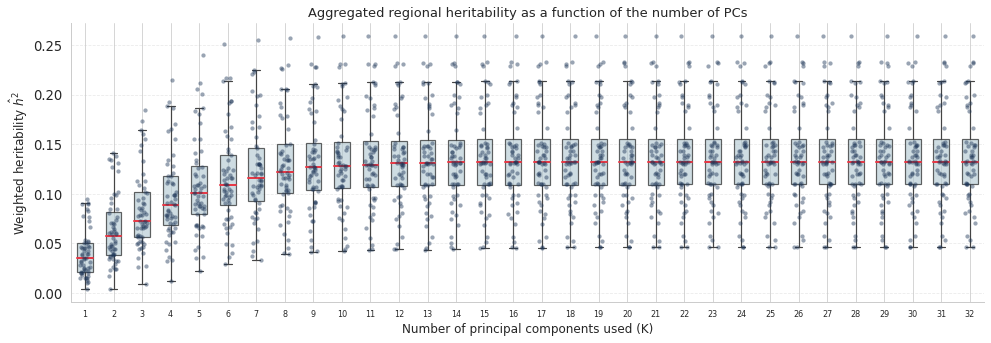

In [50]:
import matplotlib.ticker as ticker
N_PCS               = 32

# ── collect h2(K) for each region, for K = 1 … 32 ───────────────────────────
# result shape: (n_regions, 32)
all_h2 = []   # h2 weighted with renormalised EVR for top-K PCs
all_labels = []
 
for region_model in regions_models:
    region, model, pca = region_model.split('/')
 
    base_path = os.path.expanduser(
        f"{path_to_Champollion}/{region}/{model}/{pca}/{population}"
    )
    h2_path  = os.path.join(base_path, "h2", "h2_summary.tsv")
    var_path = os.path.join(path_variance, f"{region}_explained_variance_ratio.csv")
 
    if not (os.path.exists(h2_path) and os.path.exists(var_path)):
        print(f"[skip] missing data for {region} / {model}")
        continue
 
    var_df = pd.read_csv(var_path)
    var_df["pheno"] = var_df["pheno"].apply(lambda x: x + "_res")
 
    h2_df  = pd.read_csv(h2_path, sep="\t")
    merge  = pd.merge(var_df, h2_df, on="pheno")
 
    # sort by PC index just in case (dim1_res < dim2_res … )
    merge = merge.sort_values(
        "pheno",
        key=lambda s: s.str.extract(r"(\d+)", expand=False).astype(int)
    ).reset_index(drop=True)
 
    evr = np.array(merge["explained_variance_ratio"])  # shape (32,)
    h2  = np.array(merge["h2"])                        # shape (32,)
 
    # for K = 1 … 32 : use top-K PCs, renormalise EVR to sum to 1
    h2_vs_K = []
    for K in range(1, N_PCS + 1):
        evr_k  = evr[:K]
        h2_k   = h2[:K]
        w_k    = evr_k #/ evr_k.sum()          # renormalise → sums to 1
        h2_vs_K.append(np.dot(w_k, h2_k))
 
    all_h2.append(h2_vs_K)
    all_labels.append(region)
 
all_h2 = np.array(all_h2)   # shape (n_regions, 32)
print(f"Loaded {len(all_labels)} regions.")
 
# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
 
x_positions = np.arange(1, N_PCS + 1)
 
# boxplot — one box per K
bp = ax.boxplot(
    [all_h2[:, k] for k in range(N_PCS)],
    positions=x_positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False,          # individual dots drawn manually below
    medianprops=dict(color="#e63946", linewidth=2),
    boxprops=dict(facecolor="#aec6cf", alpha=0.6, linewidth=1.2),
    whiskerprops=dict(linewidth=1.2, color="#444"),
    capprops=dict(linewidth=1.2, color="#444"),
)
 
# individual dots with jitter
rng = np.random.default_rng(42)
for k in range(N_PCS):
    y      = all_h2[:, k]
    jitter = rng.uniform(-0.18, 0.18, size=len(y))
    ax.scatter(
        x_positions[k] + jitter, y,
        s=18, color="#1d3557", alpha=0.45, linewidths=0,
        zorder=3
    )
 
# cosmetics
ax.set_xlabel("Number of principal components used (K)", fontsize=12)
ax.set_ylabel("Weighted heritability $\\hat{h}^2$", fontsize=12)
ax.set_title(
    "Aggregated regional heritability as a function of the number of PCs",
    fontsize=13
)
ax.set_xticks(x_positions)
ax.set_xticklabels([str(k) for k in x_positions], fontsize=8)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
out_path = "/neurospin/dico/adufournet/2026_PCA_on_latent/ChampollionV1_32/h2_vs_npc_boxplot.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()

In [47]:
merge

,pheno,explained_variance_ratio,h2,se,lambdaGC,Mean_Chi2,Intercept
0,dim10_res,0.021024,0.1302,0.0163,1.0957,1.1100,1.0188
1,dim11_res,0.013642,0.1457,0.0157,1.0957,1.1006,0.9983
2,dim12_res,0.008019,0.0135,0.0129,1.0165,1.0194,1.0100
3,dim13_res,0.004756,0.0077,0.0128,1.0135,1.0186,1.0131
4,dim14_res,0.003892,0.0359,0.0123,1.0135,1.0165,0.9911
5,dim15_res,0.002366,0.0147,0.0115,1.0165,1.0198,1.0094
6,dim16_res,0.002317,0.0693,0.0143,1.0285,1.0336,0.9835
7,dim17_res,0.001162,0.0138,0.0114,1.0135,1.0109,1.0011
8,dim18_res,0.000885,0.0565,0.0135,1.0255,1.0371,0.9969
9,dim19_res,0.000757,0.0340,0.0123,1.0255,1.0196,0.9953


In [45]:
for region_model in regions_models:
    region, model, pca = region_model.split('/')
    base_path = os.path.expanduser(f"{path_to_Champollion}/{region}/{model}/{pca}/{population}")
    h2_path = os.path.join(base_path, "h2", "h2_summary.tsv")

    var_path = os.path.join(path_variance, f"{region}_explained_variance_ratio.csv")
    if verbose : 
        print(var_path)
    if os.path.exists(var_path):
        var_df = pd.read_csv(var_path)
        var_df["pheno"] = var_df["pheno"].apply(lambda x : x+"_res")
    
    if os.path.exists(h2_path):
        h2_df = pd.read_csv(h2_path, sep="\t")

    if os.path.exists(var_path) and os.path.exists(h2_path):
        merge = pd.merge(var_df, h2_df, on='pheno')

        evr = np.array(merge["explained_variance_ratio"])
        h2  = np.array(merge["h2"])
        se  = np.array(merge["se"])

        if verbose:
            print(f"Sum of EVR (should be ~1): {evr.sum():.6f}")

        # Weighted h²
        h2_region = np.sum(evr * h2)

        # Propagated SE: sqrt(sum of (w_k * se_k)^2) — assuming independence across PCs
        se_region = np.sqrt(np.sum((evr * se)**2))

        if verbose:
            print(f"\nWeighted h²_region : {h2_region:.4f}")
            print(f"Propagated SE      : {se_region:.4f}")
            print(f"95% CI             : [{h2_region - 1.96*se_region:.4f}, {h2_region + 1.96*se_region:.4f}]")

            # Show contribution of each PC to final estimate
            print("\nPer-PC contributions (w_k * h²_k):")
            contributions = evr * h2
            for i, (w, h, c) in enumerate(zip(evr, h2, contributions)):
                print(f"  dim{i+1:02d}: w={w:.4f}  h²={h:.4f}  contribution={c:.4f}  ({100*c/h2_region:.1f}%)")

        dic_results["region"].append(region)
        dic_results["model"].append(model)
        dic_results["h2"].append(h2_region)
        dic_results["se"].append(se_region)
    
    else : 
        print(region, model)

In [30]:
df_results = pd.DataFrame.from_dict(dic_results)
df_results[["region", "h2", "se"]].sort_values(by="h2", ascending=False)

,region,h2,se
54,SCall-SsP-SintraCing_left,0.259414,0.008959
52,SCall_left,0.232730,0.008281
35,FPO-SCu-ScCal_right,0.231334,0.009470
11,FPO-SCu-ScCal_left,0.229071,0.008951
55,SCall-SsP-SintraCing_right,0.213493,0.008083
44,ScCal-SLi_right,0.212530,0.008605
53,SCall_right,0.211159,0.008225
22,FCLp-subsc-FCLa-INSULA_left,0.199832,0.008165
20,ScCal-SLi_left,0.197606,0.007432
2,FColl-SRh_left,0.191904,0.007358


### Nb of independant loci per region (Champollion V1)

In [31]:
list_loci_path = glob.glob("/home/ad279118/ukb/26irene_AD_UKB_optim/results/Champollion_V1_32/*/*/32PCs/White/FUMA5e-08/GenomicRiskLoci.txt")

dic_nb_loci={"region":[], 
               "model":[],
               "loci_nb":[], }

for path in list_loci_path:
    region = path.split('/')[-6]
    model = path.split('/')[-5]

    dic_nb_loci["region"].append(region)
    dic_nb_loci["model"].append(model)
    dic_nb_loci["loci_nb"].append(len(pd.read_csv(path, sep='\t')))

df_nb_loci = pd.DataFrame.from_dict(dic_nb_loci)
#df_nb_loci.sort_values(by="loci_nb", ascending=False)

### Nb of independant loci per region (Morpho)

In [32]:
list_loci_path = glob.glob("/home/ad279118/ukb/25irene_AD_sulciMorpho/results/*/White/FUMA/GenomicRiskLoci.txt")

dic_morpho_nb_loci={"region":[], 
               "loci_nb":[], }

for path in list_loci_path:
    region = path.split('/')[-4]

    dic_morpho_nb_loci["region"].append(region)
    dic_morpho_nb_loci["loci_nb"].append(len(pd.read_csv(path, sep='\t')))

df_morpho_nb_loci = pd.DataFrame.from_dict(dic_morpho_nb_loci)
#df_morpho_nb_loci.sort_values(by="loci_nb", ascending=False)

### Volume of the region

In [33]:
list_volume_path = glob.glob("/neurospin/dico/data/deep_folding/current/models/Champollion_V1_after_ablation/*/*/.hydra/config.yaml")

def product(lst):
    p = 1
    for i in lst:
        p *= i
    return p

dic_volume={"region":[], 
            "model":[],
            "volume":[], }

for path in list_volume_path:
    region = path.split('/')[-4]
    model = path.split('/')[-3]
    volume_target = "    input_size: "

    with open(path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if volume_target in line:
            try:
                # Extract the float before the parentheses
                volume_str = line.replace(volume_target, "").strip().replace('(', "").replace(')', "").split(",")[1:4]
                volume_value = [float(x) for x in volume_str]
                if verbose:
                    print(region, model)
                    print(volume_value)

                dic_volume["region"].append(region)
                dic_volume["model"].append(model)
                dic_volume["volume"].append(product(volume_value))
            except ValueError:
                print(f"Warning: Could not extract volume from line: {line.strip()}")

df_volume = pd.DataFrame.from_dict(dic_volume)


### Merge all three

In [34]:
import seaborn as sns

merged_df = pd.merge(df_nb_loci, df_results, on=["region","model"])
merged_df = pd.merge(merged_df, df_volume, on=["region","model"])
merged_df = merged_df.rename(columns={"h2":"SNP-based h²", "loci_nb":"Loci number Champollion V1", "volume":"Region \nvolume"})
merged_df = pd.merge(merged_df, df_morpho_nb_loci, on="region")
merged_df = merged_df.rename(columns={"loci_nb":"Loci number Morpho"})

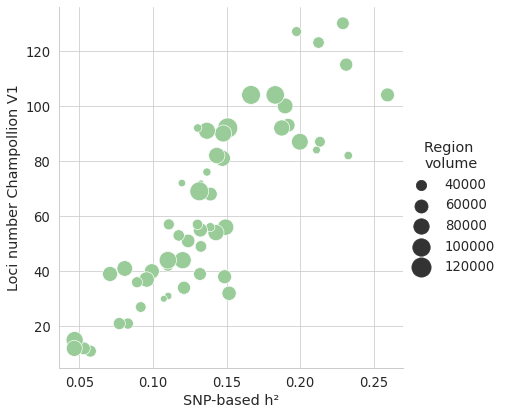

In [16]:
#plt.scatter(merged_df["loci_nb"], merged_df["h2"])
#plt.xlabel("Nb of ind. loci")
#plt.ylabel("Regional h²")
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
sns_plot = sns.relplot(x="SNP-based h²", y="Loci number Champollion V1", size="Region \nvolume",
            sizes=(40, 400), alpha=1, color='#99cc99',
            height=6, data=merged_df)
sns_plot.figure.savefig('/neurospin/dico/adufournet/2026_Nature/images/heritability_loci_number.png',dpi=600)

In [26]:
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(merged_df['Loci number Champollion V1'], merged_df['SNP-based h²'])
print(slope, intercept, r_value, p_value, std_err)
y_pred = slope * merged_df['Loci number Champollion V1'] + intercept

r2 = r2_score(merged_df['SNP-based h²'], y_pred)
r2

0.001353045901920452 0.05324556195285582 0.858238474940861 2.8523816980276713e-17 0.00011011274328025582


0.7365732798688145

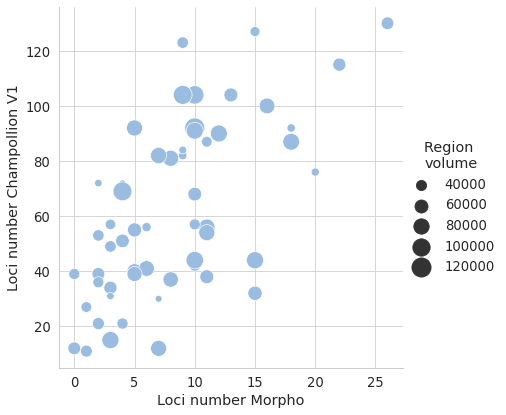

In [17]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
sns_plot = sns.relplot(x="Loci number Morpho", y="Loci number Champollion V1", size="Region \nvolume",
            sizes=(40, 400), alpha=1, color='#99bce0',
            height=6, data=merged_df)
sns_plot.figure.savefig('/neurospin/dico/adufournet/2026_Nature/images/loci_number.png',dpi=600)

In [15]:
merged_df = pd.read_csv('/neurospin/dico/adufournet/2026_Nature/images/globalheritability_table.csv')

In [27]:
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(merged_df['Region \nvolume'], merged_df['SNP-based h²'])
print(slope, intercept, r_value, p_value, std_err)
y_pred = slope * merged_df['Region \nvolume'] + intercept

coefficient_of_dermination = r2_score(merged_df['SNP-based h²'], y_pred)
coefficient_of_dermination

-7.027557625424888e-09 0.1380213985162832 -0.003829320697904122 0.9776543504741064 2.4973684002847866e-07


1.4663697007422094e-05

In [42]:
merged_df.corr()

,Loci number Champollion V1,SNP-based h²,se,Region \nvolume,Loci number Morpho,N_tested,N_replicated,Replication_%
Loci number Champollion V1,1.000000,0.858238,0.723897,0.119125,0.637490,0.988115,0.960396,0.518628
SNP-based h²,0.858238,1.000000,0.935620,-0.003829,0.623857,0.859913,0.844362,0.505631
se,0.723897,0.935620,1.000000,-0.057868,0.641416,0.746011,0.732717,0.397372
Region \nvolume,0.119125,-0.003829,-0.057868,1.000000,0.138002,0.059342,0.056374,0.023211
Loci number Morpho,0.637490,0.623857,0.641416,0.138002,1.000000,0.650940,0.616919,0.341749
N_tested,0.988115,0.859913,0.746011,0.059342,0.650940,1.000000,0.970155,0.527563
N_replicated,0.960396,0.844362,0.732717,0.056374,0.616919,0.970155,1.000000,0.656402
Replication_%,0.518628,0.505631,0.397372,0.023211,0.341749,0.527563,0.656402,1.000000


In [39]:
replication = pd.read_csv('/home/ad279118/ukb/26irene_AD_UKB_optim/results/Champollion_V1_32/replication_summary_5e-08.tsv', sep="\t")
merged_df = pd.merge(merged_df, replication, on='region')

In [40]:
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(merged_df['N_replicated'], merged_df['SNP-based h²'])
print(slope, intercept, r_value, p_value, std_err)
y_pred = slope * merged_df['N_replicated'] + intercept

r2 = r2_score(merged_df['SNP-based h²'], y_pred)
print("r2 :", r2)

0.0028143215949892487 0.06630667223870623 0.8443623853402931 2.944934488607847e-16 0.0002430123674496757
r2 : 0.7129478377775491


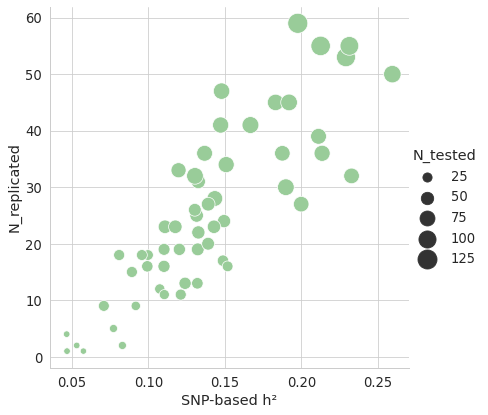

In [41]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
sns_plot = sns.relplot(x="SNP-based h²", y="N_replicated", size="N_tested",
            sizes=(40, 400), alpha=1, color='#99cc99',
            height=6, data=merged_df)
sns_plot.figure.savefig('/neurospin/dico/adufournet/2026_Nature/images/replication_loci_number.png',dpi=600)

In [ ]:
#merged_df.sort_values(by="SNP-based h²", ascending=False).to_csv('/neurospin/dico/adufournet/2026_Nature/images/globalheritability_table.csv', index=False)